In [1]:
import re
import gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
os.getcwd()

'/Users/jinyecai/Desktop/ML_Mortgage'

In [74]:
ROOT = Path('/Users/jinyecai/Desktop/ML_Mortgage')
LAYOUT_XLSX = Path("file_layout.xlsx") 
OUTDIR = Path("processed_mortgage")
YEARS = list(range(2016, 2026))

# 1) Read origination column names from file_layout.xlsx
def normalize_col(s: str) -> str:
    s = str(s).strip()
    s = s.replace("%", "pct").replace("&", "and").replace("/", "_").replace("-", "_")
    s = re.sub(r"[^\w\s]", "", s)
    s = re.sub(r"\s+", "_", s.lower()).strip("_")
    s = re.sub(r"_+", "_", s)
    return s

def load_orig_columns(layout_xlsx):
    xls = pd.ExcelFile(layout_xlsx)
    df = pd.read_excel(xls, sheet_name="Origination Data File")

    # layout: Position/Attribute Name/Type/Description
    df = df.copy()
    df.columns = [f"c{i}" for i in range(df.shape[1])]

    pos_col = df.columns[0]
    name_col = df.columns[1]

    df = df[pd.to_numeric(df[pos_col], errors="coerce").notna()].copy()
    df["position"] = df[pos_col].astype(int)
    df["attr_name"] = df[name_col].astype(str).str.strip()

    cols = [normalize_col(x) for x in df.sort_values("position")["attr_name"].tolist()]
    return cols

orig_cols = load_orig_columns(LAYOUT_XLSX)

# 2) read orig txt,add header
def read_pipe_txt_noheader(txt_path: Path, expected_cols: list, file_year):
    df = pd.read_csv(
        txt_path,
        sep="|",
        header=None,
        dtype="string",      
        na_filter=False,     
        engine="python"
    )

    while df.shape[1] > 0:
        last_col = df.iloc[:, -1]
        if (last_col == "").all():
            df = df.iloc[:, :-1]
        else:
            break

    df.columns = expected_cols

    if file_year is not None:
        df["file_year"] = int(file_year)

    return df

# Merge origination data from 2016 to 2025

orig_list = []

for y in YEARS:
    f = ROOT / f"sample_{y}" / f"sample_orig_{y}.txt"
    dfo = read_pipe_txt_noheader(f, orig_cols, file_year=y)
    orig_list.append(dfo)

orig_df = pd.concat(orig_list, ignore_index=True)

print("orig_df shape:", orig_df.shape)
# orig_df.head()

# handle numeric columns
def to_num(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c].replace("", pd.NA), errors="coerce")

num_cols = [
    "credit_score",
    "original_upb",
    "original_loan_to_value_ltv",
    "original_combined_loan_to_value_cltv",
    "original_debt_to_income_dti_ratio",
    "original_interest_rate",
    "loan_term",
    "number_of_borrowers",
    "number_of_units",
    "postal_code",
]
to_num(orig_df, num_cols)

# handle dates
def parse_yyyymm(series):
    s = series.astype("string").str.strip()
    s = s.where(s.str.fullmatch(r"\d{6}"), pd.NA)
    return pd.to_datetime(s, format="%Y%m", errors="coerce")

for c in ["first_payment_date", "maturity_date"]:
    if c in orig_df.columns:
        orig_df[c + "_dt"] = parse_yyyymm(orig_df[c])

# clean empty vals,set as na（only apply to object/string）
for c in orig_df.columns:
    if pd.api.types.is_string_dtype(orig_df[c]):
        orig_df[c] = orig_df[c].replace("", pd.NA)

# export parquet
orig_out = OUTDIR / "orig_only_2016_2025.parquet"
orig_df.to_parquet(orig_out, index=False)



orig_df shape: (487500, 33)


In [13]:
import numpy as np
import pandas as pd
from pathlib import Path
pd.set_option('display.max_colwidth', 10)

OUTDIR = Path("processed_mortgage")
orig_out = OUTDIR / "orig_only_2016_2025.parquet"
orig_df = pd.read_parquet(orig_out)

def clean_range(series, low=None, high=None):
    s = pd.to_numeric(series, errors="coerce")
    if low is not None:
        s = s.where(s >= low)
    if high is not None:
        s = s.where(s <= high)
    return s

# Core cleaned variables for EDA/modeling prep
orig_df["credit_score_clean"] = clean_range(orig_df["credit_score"], 300, 850)
orig_df["ltv_clean"] = clean_range(orig_df["original_loan_to_value_ltv"], 0, 200)
orig_df["dti_clean"] = clean_range(orig_df["original_debt_to_income_dti_ratio"], 0, 100)
orig_df["orig_rate_clean"] = clean_range(orig_df["original_interest_rate"], 0, 20)
orig_df["original_upb_clean"] = clean_range(orig_df["original_upb"], 1, None)

# Quick QC summary

summary_rows = []
for c in qc_cols:
    s = pd.to_numeric(orig_df[c], errors="coerce")
    summary_rows.append({
        "variable": c,
        "missing_rate": s.isna().mean(),
        "count_nonmissing": int(s.notna().sum()),
        "min": s.min(),
        "p01": s.quantile(0.01),
        "p05": s.quantile(0.05),
        "median": s.quantile(0.50),
        "p95": s.quantile(0.95),
        "p99": s.quantile(0.99),
        "max": s.max(),
        "mean": s.mean(),
        "std": s.std(),
    })

qc_summary = pd.DataFrame(summary_rows)

qc_summary

# qc_summary.to_excel('detail_summary.xlsx')

,variable,missing_rate,count_nonmissing,min,p01,p05,median,p95,p99,max,mean,std
0,credit...,0.000222,487392,300.000,632.000,664.00,759.0,808.00,816.000,848.000,749.85...,45.311430
1,ltv_clean,0.000012,487494,3.000,22.000,37.00,79.0,95.00,97.000,194.000,73.816178,18.139914
2,dti_clean,0.010029,482611,1.000,12.000,18.00,37.0,49.00,50.000,65.000,35.796677,9.548230
3,orig_r...,0.000000,487500,1.625,2.375,2.75,4.5,7.25,7.875,9.125,4.786680,1.494086
4,origin...,0.000000,487500,10000.000,54990.000,85000.00,250000.0,586000.00,755000...,178100...,280722...,156246...


In [66]:
orig_df.columns

Index(['credit_score', 'first_payment_date', 'first_time_homebuyer_flag', 'maturity_date', 'metropolitan_statistical_area_msa_or_metropolitan_division', 'mortgage_insurance_percentage_mi_pct',
       'number_of_units', 'occupancy_status', 'original_combined_loan_to_value_cltv', 'original_debt_to_income_dti_ratio', 'original_upb', 'original_loan_to_value_ltv', 'original_interest_rate',
       'channel', 'prepayment_penalty_mortgage_ppm_flag', 'amortization_type_formerly_product_type', 'property_state', 'property_type', 'postal_code', 'loan_sequence_number', 'loan_purpose',
       'original_loan_term', 'number_of_borrowers', 'seller_name', 'servicer_name', 'super_conforming_flag', 'pre_harp_loan_sequence_number', 'program_indicator', 'harp_indicator',
       'property_valuation_method', 'interest_only_i_o_indicator', 'mortgage_insurance_cancellation_indicator', 'file_year', 'first_payment_date_dt', 'maturity_date_dt', 'credit_score_clean',
       'ltv_clean', 'orig_rate_clean', 'original


Loan count by file_year:
   file_year  n_loans
0       2016    50000
1       2017    50000
2       2018    50000
3       2019    50000
4       2020    50000
5       2021    50000
6       2022    50000
7       2023    50000
8       2024    50000
9       2025    37500


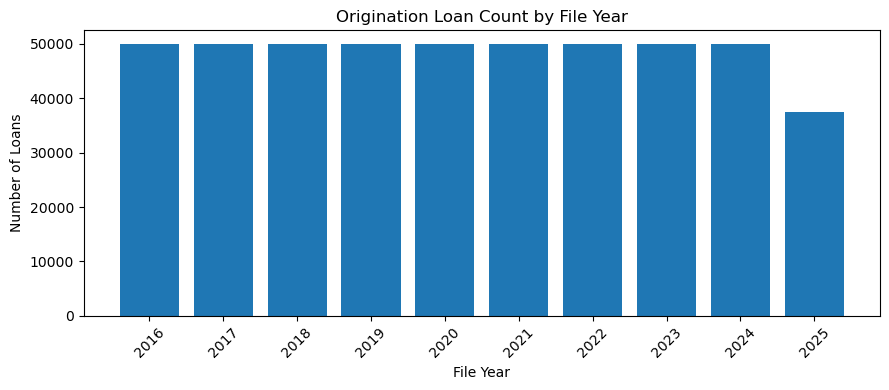

In [31]:
# EDA 1.1

year_counts = orig_df.groupby("file_year").size().reset_index(name="n_loans")
print("\nLoan count by file_year:")
print(year_counts)

year_counts.to_csv(OUTDIR / "eda_orig_count_by_year.csv", index=False)

plt.figure(figsize=(9, 4))
plt.bar(year_counts["file_year"].astype(str), year_counts["n_loans"])
plt.title("Origination Loan Count by File Year")
plt.xlabel("File Year")
plt.ylabel("Number of Loans")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# plt.savefig(OUTDIR / "eda_orig_count_by_year.png", dpi=150)
# plt.close()

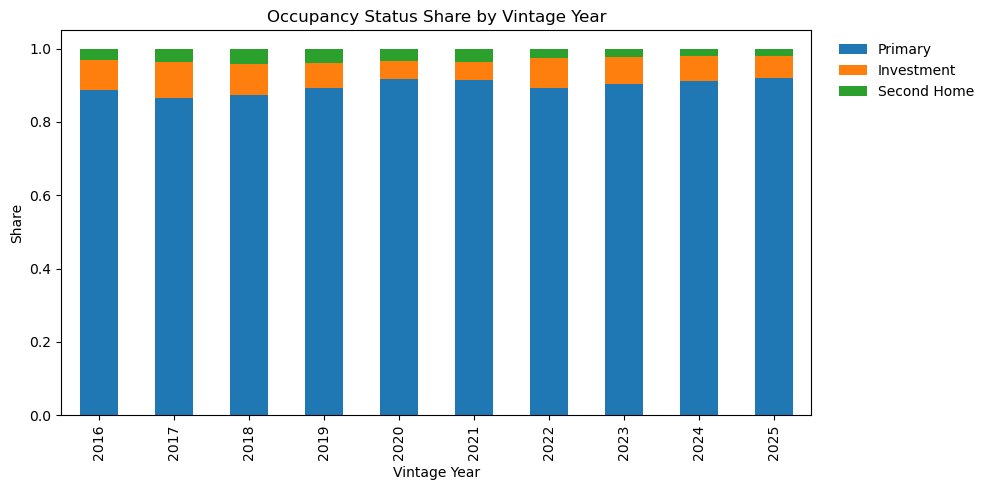

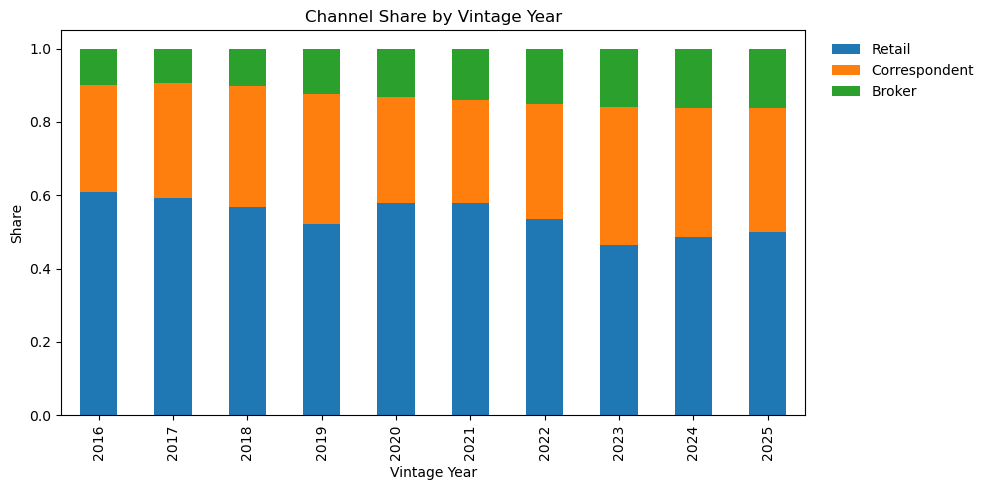

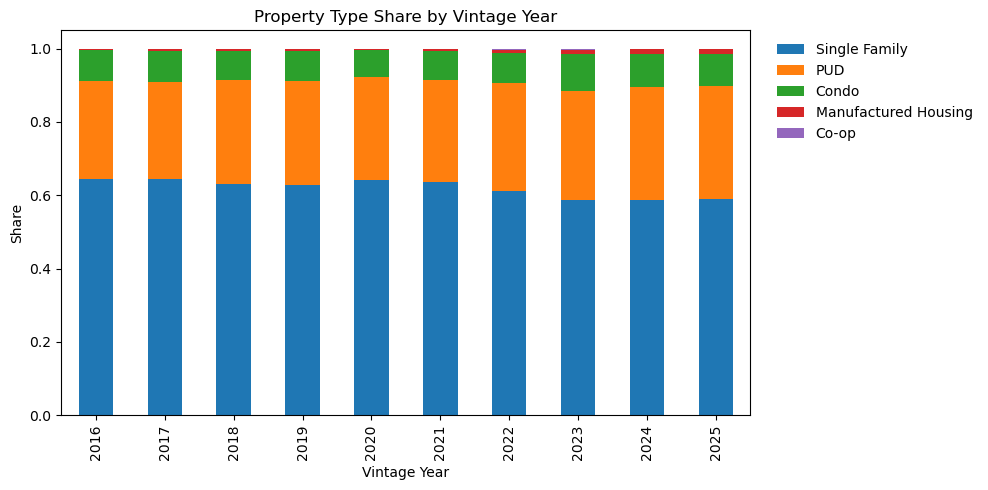

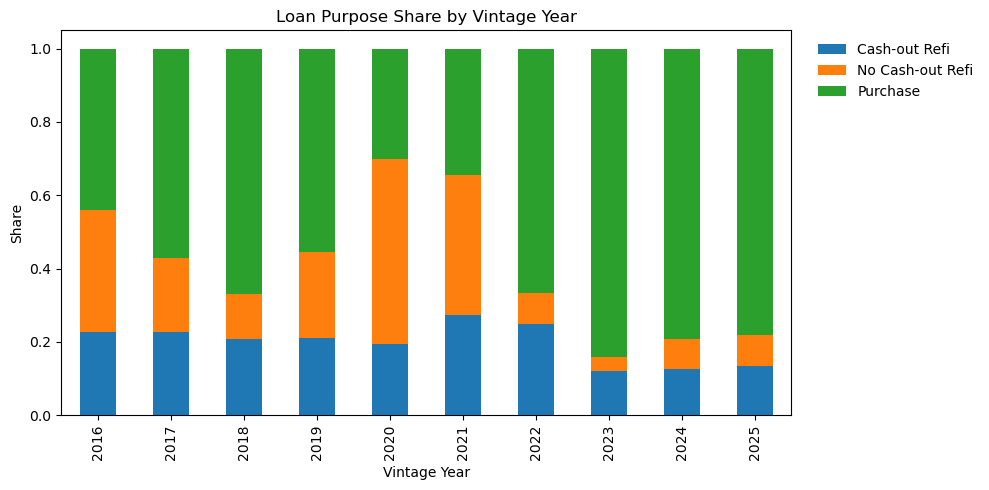

loan_purpose,Cash-out Refi,No Cash-out Refi,Purchase
file_year,,,
2016,0.225780,0.33478,0.439440
2017,0.227960,0.20140,0.570640
2018,0.208760,0.12298,0.668260
2019,0.211380,0.23322,0.555400
2020,0.192980,0.50690,0.300120
2021,0.274460,0.38136,0.344180
2022,0.247880,0.08670,0.665420
2023,0.120100,0.03916,0.840740
2024,0.125380,0.08208,0.792540


In [32]:
import pandas as pd
import matplotlib.pyplot as plt

LABEL_MAPS = {
    "loan_purpose": {
        "P": "Purchase",
        "C": "Cash-out Refi",
        "N": "No Cash-out Refi",
    },
    "occupancy_status": {
        "P": "Primary",
        "I": "Investment",
        "S": "Second Home",
    },
    "channel": {
        "R": "Retail",
        "C": "Correspondent",
        "B": "Broker",
    },
    "property_type": {
        "SF": "Single Family",
        "PU": "PUD",
        "CO": "Condo",
        "MH": "Manufactured Housing",
        "CP": "Co-op",  
    }
}

def plot_cat_share_by_vintage(
    df,
    cat_col,
    year_col="file_year",
    top_n=None,
    category_order=None,
    rename_map=None,
    title=None,
    figsize=(10, 5)
):
    """
    Plot stacked bar chart of category shares by vintage year.
    """
    tmp = df[[year_col, cat_col]].copy()

    # Clean strings
    tmp[cat_col] = tmp[cat_col].astype("string").str.strip()
    tmp[cat_col] = tmp[cat_col].fillna("Missing")

    # If top_n specified, keep top categories overall and group others into 'Other'
    if top_n is not None:
        top_cats = tmp[cat_col].value_counts().head(top_n).index
        tmp[cat_col] = tmp[cat_col].where(tmp[cat_col].isin(top_cats), "Other")

    # Count and convert to share within each year
    ct = pd.crosstab(tmp[year_col], tmp[cat_col], normalize="index")

    # Reorder columns if provided
    if category_order is not None:
        existing = [c for c in category_order if c in ct.columns]
        remaining = [c for c in ct.columns if c not in existing]
        ct = ct[existing + remaining]

    # Rename columns for display
    if rename_map is None:
        rename_map = LABEL_MAPS.get(cat_col, {})
    ct_plot = ct.rename(columns=rename_map)

    # Plot
    ax = ct_plot.plot(
        kind="bar",
        stacked=True,
        figsize=figsize
    )
    ax.set_title(title or f"{cat_col} share by vintage year")
    ax.set_xlabel("Vintage Year")
    ax.set_ylabel("Share")
    ax.legend(title=None, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(OUTDIR / f"eda_{cat_col}_share_by_year.png", dpi=150)
    plt.show()

    return ct_plot  

plot_cat_share_by_vintage(
    orig_df,
    cat_col="occupancy_status",
    title="Occupancy Status Share by Vintage Year",
    category_order=["P", "I", "S"]   # Primary / Investment / Second Home
)
plot_cat_share_by_vintage(
    orig_df,
    cat_col="channel",
    title="Channel Share by Vintage Year",
    category_order=["R", "C", "B"]   # Retail / Correspondent / Broker
)
plot_cat_share_by_vintage(
    orig_df,
    cat_col="property_type",
    title="Property Type Share by Vintage Year",
    category_order=["SF", "PU", "CO", "MH", "CP"]
)
plot_cat_share_by_vintage(
    orig_df,
    cat_col="loan_purpose",
    title="Loan Purpose Share by Vintage Year",
    category_order=["C", "N", "P"]  
)

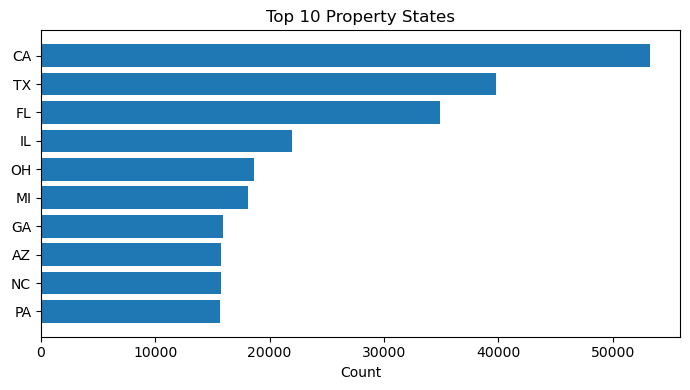

In [35]:
s = orig_df["property_state"].astype("string").str.strip()
vc = s.value_counts(dropna=False).head(10)

plt.figure(figsize=(7,4))
plt.barh(vc.index[::-1].astype(str), vc.values[::-1])  # horizontal bar
plt.title("Top 10 Property States")
plt.xlabel("Count")
plt.tight_layout()
plt.savefig(OUTDIR / f"eda_property_state_share_by_year.png", dpi=150)
plt.show()

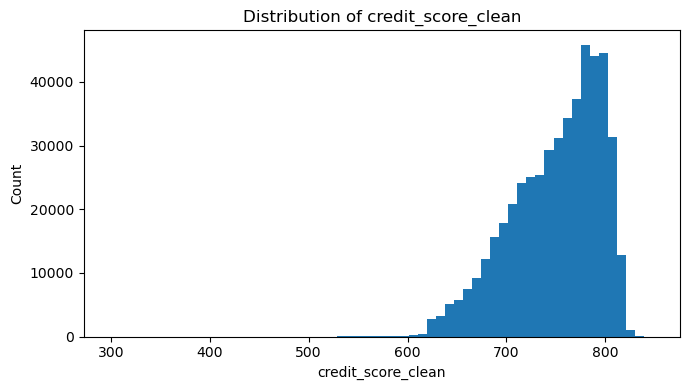

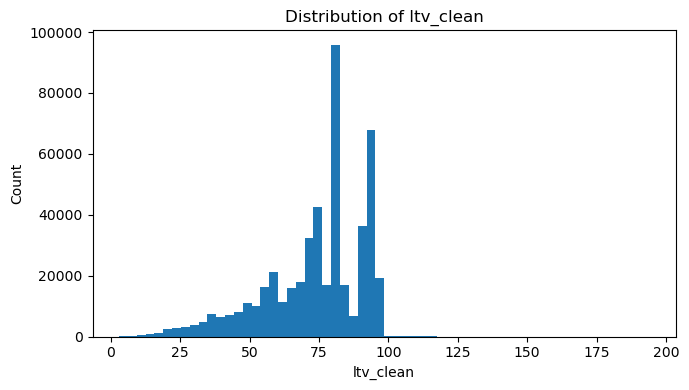

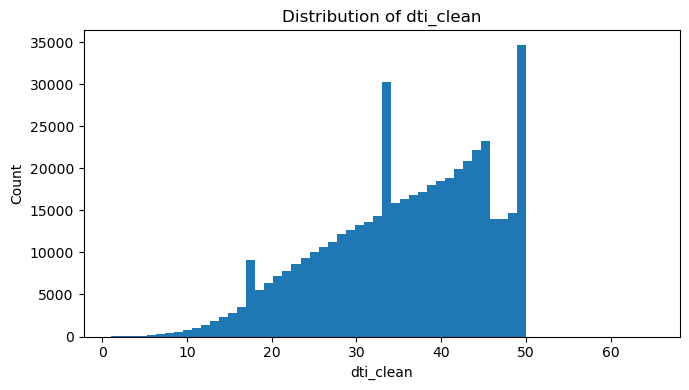

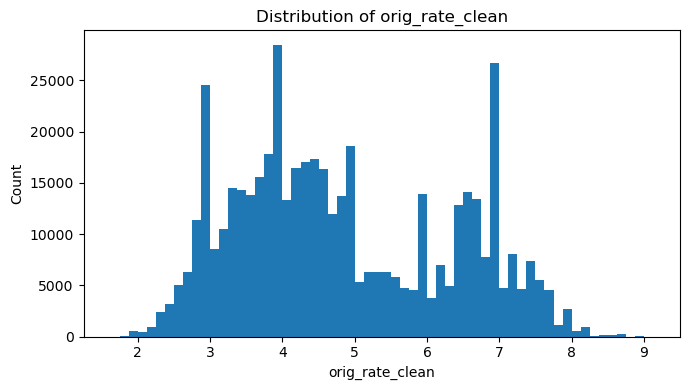

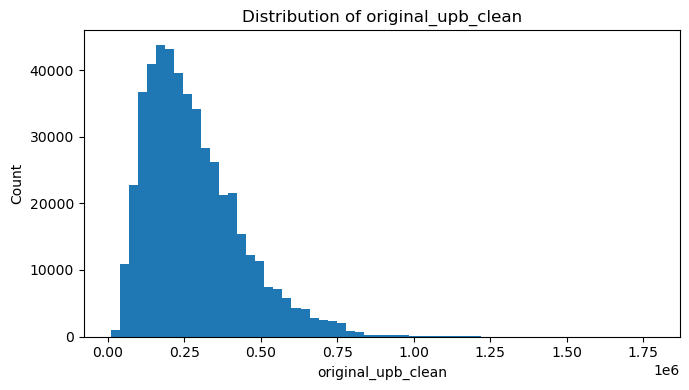

In [36]:
# data histogram
def save_hist(df, col, bins=50, outdir=OUTDIR):
    if col not in df.columns:
        return
    s = df[col].dropna()
    if s.empty:
        return
    plt.figure(figsize=(7,4))
    plt.hist(s, bins=bins)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    # plt.savefig(outdir / f"hist_{col}.png", dpi=150)
    # plt.close()
    plt.show()

for c in ["credit_score_clean", "ltv_clean", "dti_clean", "orig_rate_clean", "original_upb_clean"]:
    if c in orig_df.columns:
            save_hist(orig_df, c, bins=60)

In [37]:
# ltv = pd.to_numeric(orig_df["original_loan_to_value_ltv"], errors="coerce")

# print(ltv.value_counts(dropna=False).sort_index().tail(30))
# print("share in [999, 9999, 0]:", ltv.isin([999, 9999, 0]).mean())
# print("max:", ltv.max())

In [38]:
# Median by year
year_summary_cols = []
for c in ["credit_score", "original_loan_to_value_ltv", "original_interest_rate", "original_upb",'original_debt_to_income_dti_ratio']:
    if c in orig_df.columns:
        year_summary_cols.append(c)

if year_summary_cols:
    year_median = orig_df.groupby("file_year")[year_summary_cols].median().reset_index()
    print("\nMedian by file_year:")
    print(year_median)
    year_median.to_csv(OUTDIR / "eda_orig_median_by_year.csv", index=False)

    for c in year_summary_cols:
        plt.figure(figsize=(8,4))
        plt.plot(year_median["file_year"], year_median[c], marker="o")
        plt.title(f"Median {c} by Vintage Year")
        plt.xlabel("Vintage Year")
        plt.ylabel(f"Median {c}")
        plt.tight_layout()
        plt.savefig(OUTDIR / f"line_median_{c}_by_year.png", dpi=150)
        plt.close()


Median by file_year:
   file_year  credit_score  original_loan_to_value_ltv  original_interest_rate  original_upb  original_debt_to_income_dti_ratio
0       2016      757.0          78.0                        3.75                215000.0          36.0                        
1       2017      752.0          80.0                        4.23                207000.0          37.0                        
2       2018      753.0          80.0                        4.75                207000.0          37.0                        
3       2019      757.0          80.0                       4.125                232000.0          37.0                        
4       2020      767.0          74.0                       3.125                263000.0          34.0                        
5       2021      760.0          72.0                        2.99                259000.0          35.0                        
6       2022      751.0          80.0                        5.25                2